<div align="center">

<img src="laptop.jpeg" width="250">

<h1 style="color:black; font-weight:bold;">
Laptop Price Prediction - Regression
</h1>

</div>

<h3 style="color:red">
In this study, outlier analysis was applied to remove extremely high-priced laptops, and the Random Forest Regression model achieved the best performance with an R² score of 0.867 compared to the other models.
</h3>

##### Project 
1. Libraries
2. Load Dataset
3. Data Exploration
4. Feature Engineering
5. Data Cleaning
6. Encoding
7. Train-Test Split
8. Model Building
9. Model Evaluation
10. Hyperparameter Tuning
11. Final Results

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
df = pd.read_csv("laptop_data.csv")

df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [31]:
# Checking Type Data of Columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [33]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [37]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [38]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [41]:
## Top 10 Brands
# Top 10 Companies
company = laptop['Company'].value_counts()

company_10 = company.head(10).sort_values(ascending=False)

print(company_10)

Company
Dell       297
Lenovo     297
HP         274
Asus       158
Acer       103
MSI         54
Toshiba     48
Apple       21
Samsung      9
Razer        7
Name: count, dtype: int64


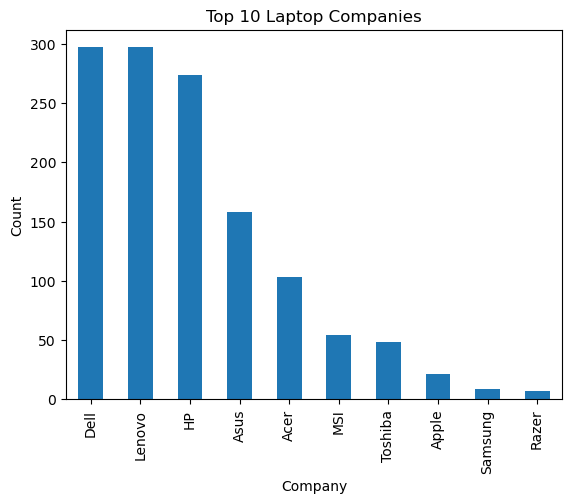

In [42]:
import matplotlib.pyplot as plt

company_10.plot(
    kind='bar'
)

plt.xlabel("Company")
plt.ylabel("Count")

plt.title("Top 10 Laptop Companies")

plt.show()

In [43]:
# Top 5 RAM Used in Laptop
ram = laptop['Ram'].value_counts()
ram_5 = ram.head(5).sort_values(ascending=False)

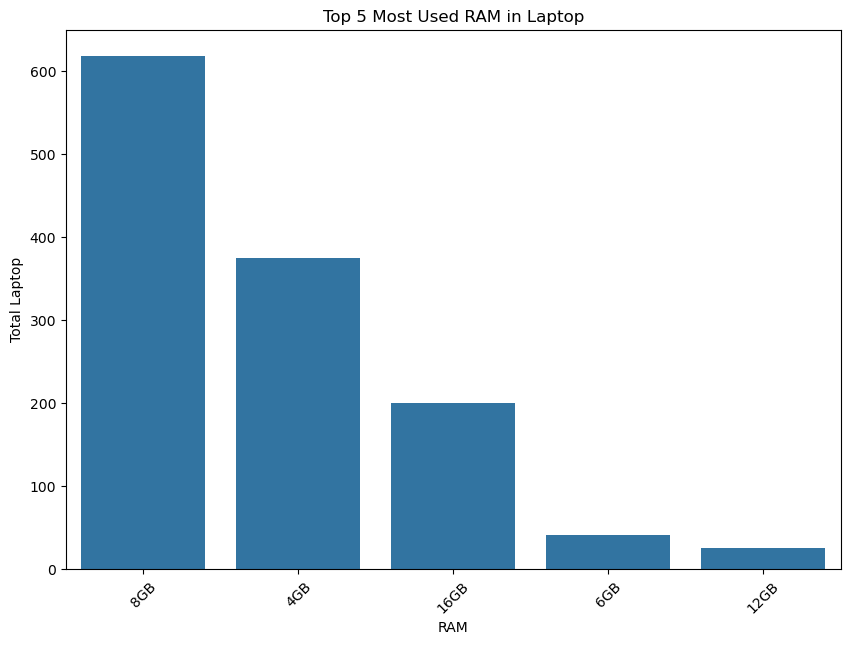

In [44]:
plt.figure(figsize=(10, 7))

sns.barplot(x=ram_5.index, y=ram_5)
plt.title('Top 5 Most Used RAM in Laptop')
plt.xlabel('RAM')
plt.ylabel('Total Laptop')
plt.xticks(rotation=45)
plt.show()

In [46]:
# Top 5 Type of RAM
# Top RAM values
ram = laptop['Ram'].value_counts()

ram_5 = ram.head(5).sort_values(ascending=False)

print(ram_5)

Ram
8GB     619
4GB     375
16GB    200
6GB      41
12GB     25
Name: count, dtype: int64


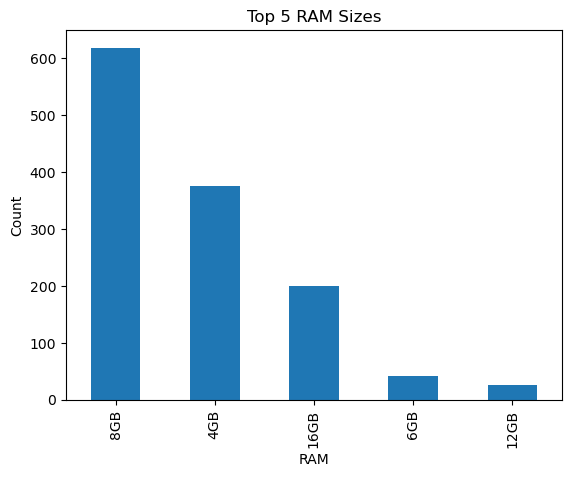

In [48]:
ram_5.plot(kind='bar')

plt.xlabel("RAM")
plt.ylabel("Count")

plt.title("Top 5 RAM Sizes")

plt.show()

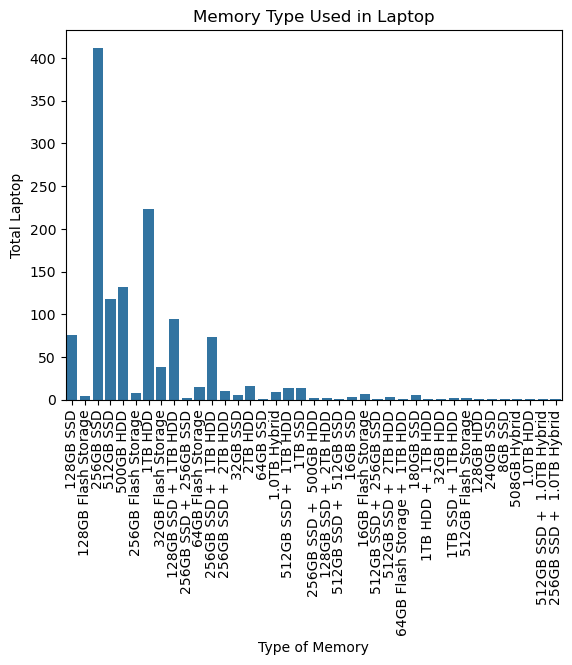

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# SSD / HDD distribution
sns.countplot(
    x=laptop['Memory']
)

plt.title('Memory Type Used in Laptop')

plt.xlabel('Type of Memory')

plt.ylabel('Total Laptop')

plt.xticks(rotation=90)

plt.show()

In [50]:
# Top 5 Used Memory Types

memory = laptop['Memory'].value_counts()

memory_5 = memory.head(5).sort_values(ascending=False)

print(memory_5)

Memory
256GB SSD               412
1TB HDD                 223
500GB HDD               132
512GB SSD               118
128GB SSD +  1TB HDD     94
Name: count, dtype: int64


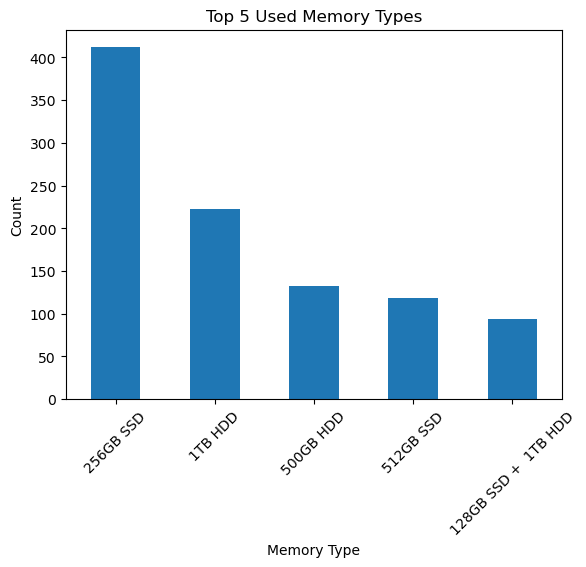

In [51]:
memory_5.plot(kind='bar')

plt.xlabel("Memory Type")
plt.ylabel("Count")

plt.title("Top 5 Used Memory Types")

plt.xticks(rotation=45)

plt.show()

In [54]:
# Top 5 CPU Used


cpu = laptop['Cpu'].value_counts()

cpu_5 = cpu.head(5).sort_values(ascending=False)

print(cpu_5)

Cpu
Intel Core i5 7200U 2.5GHz     190
Intel Core i7 7700HQ 2.8GHz    146
Intel Core i7 7500U 2.7GHz     134
Intel Core i7 8550U 1.8GHz      73
Intel Core i5 8250U 1.6GHz      72
Name: count, dtype: int64


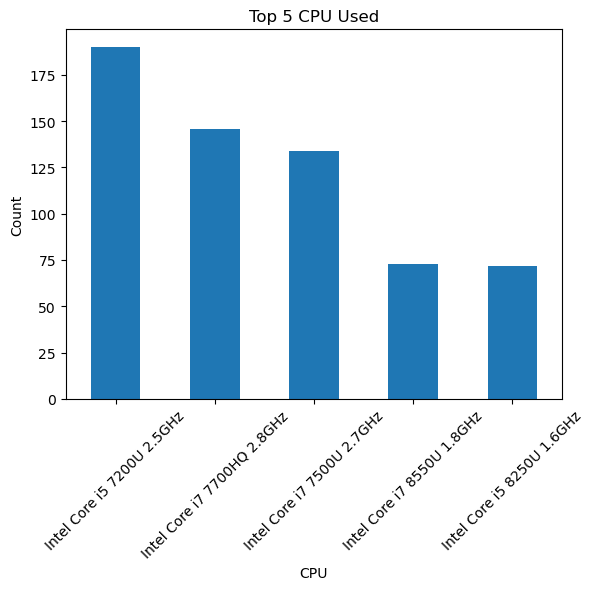

In [55]:
cpu_5.plot(kind='bar')

plt.xlabel("CPU")
plt.ylabel("Count")

plt.title("Top 5 CPU Used")

plt.xticks(rotation=45)

plt.show()

In [56]:
# Top 5 GPU Used
gpu = laptop['Gpu'].value_counts()
gpu_5 = gpu.head(5).sort_values(ascending=False)

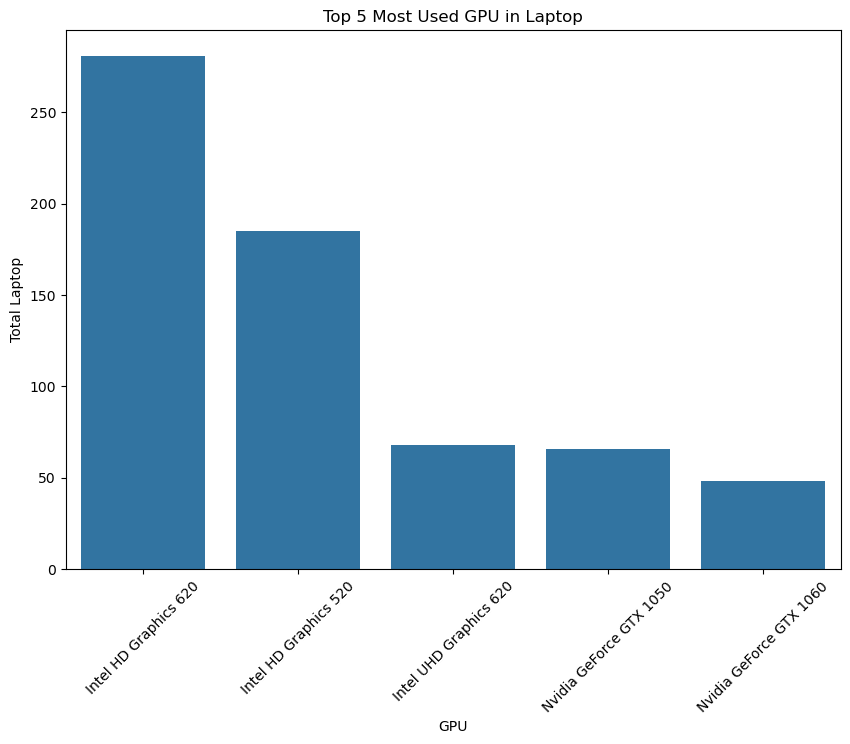

In [57]:
plt.figure(figsize=(10, 7))

sns.barplot(x=gpu_5.index, y=gpu_5)
plt.title('Top 5 Most Used GPU in Laptop')
plt.xlabel('GPU')
plt.ylabel('Total Laptop')
plt.xticks(rotation=45)
plt.show()

In [58]:
# Top 5 Operating Systems Used

os = laptop['OpSys'].value_counts()

os_5 = os.head(5).sort_values(ascending=False)

print(os_5)

OpSys
Windows 10    1072
No OS           66
Linux           62
Windows 7       45
Chrome OS       27
Name: count, dtype: int64


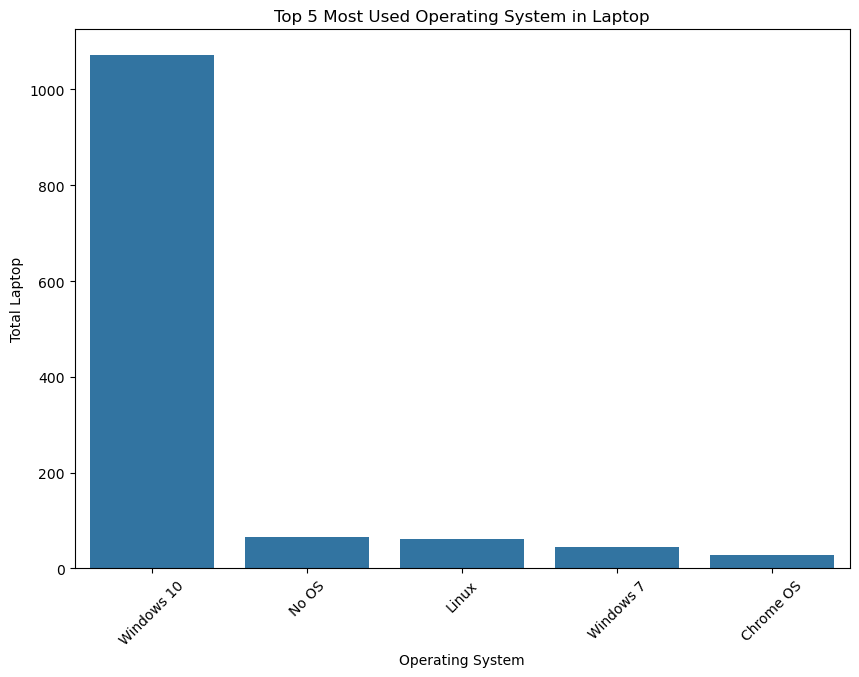

In [59]:
plt.figure(figsize=(10, 7))

sns.barplot(x=os_5.index, y=os_5)
plt.title('Top 5 Most Used Operating System in Laptop')
plt.xlabel('Operating System')
plt.ylabel('Total Laptop')
plt.xticks(rotation=45)
plt.show()

In [60]:
# Using a Numeric Column for Features
num_col = laptop.select_dtypes(include=['int64', 'float64']).columns
num_col = laptop[num_col]
num_col.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1303 non-null   int64  
 1   Inches      1303 non-null   float64
 2   Price       1303 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 30.7 KB


Text(0.5, 1.0, 'Correlation Matrix Heatmap')

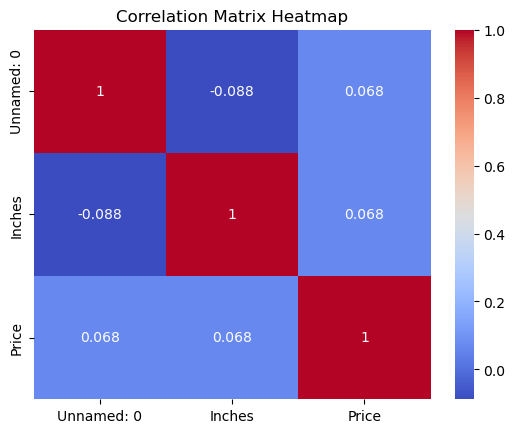

In [61]:
# Create a Correlation Matrix Heatmap
sns.heatmap(num_col.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Matrix Heatmap")

In [68]:
laptop.select_dtypes(include='object').columns

Index(['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory',
       'Gpu', 'OpSys', 'Weight'],
      dtype='object')

In [69]:
laptop = pd.get_dummies(
    laptop,
    drop_first=True)

In [70]:
laptop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Columns: 523 entries, Unnamed: 0 to Weight_4kg
dtypes: bool(520), float64(2), int64(1)
memory usage: 692.3 KB


In [71]:
bool_cols = laptop.select_dtypes(include='bool').columns

laptop[bool_cols] = laptop[bool_cols].astype(int)

In [72]:
laptop.select_dtypes(include='object').columns

Index([], dtype='object')

In [73]:
laptop = laptop.loc[ :,~laptop.columns.str.contains('^Unnamed')]

In [74]:
laptop.columns

Index(['Inches', 'Price', 'Company_Apple', 'Company_Asus', 'Company_Chuwi',
       'Company_Dell', 'Company_Fujitsu', 'Company_Google', 'Company_HP',
       'Company_Huawei',
       ...
       'Weight_4.2kg', 'Weight_4.33kg', 'Weight_4.36kg', 'Weight_4.3kg',
       'Weight_4.42kg', 'Weight_4.4kg', 'Weight_4.5kg', 'Weight_4.6kg',
       'Weight_4.7kg', 'Weight_4kg'],
      dtype='object', length=522)

In [75]:
X = laptop.drop("Price", axis=1)

y = laptop["Price"]

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [77]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
lr_pred = lr.predict(X_test)

In [79]:
from sklearn.metrics import (r2_score,mean_absolute_error,mean_squared_error)
print("Linear Regression R2:",r2_score(y_test, lr_pred))
print("MAE:",mean_absolute_error(y_test, lr_pred))
print("MSE:",mean_squared_error(y_test, lr_pred))

Linear Regression R2: 0.8000280945808969
MAE: 10952.491481032137
MSE: 288335628.7195166


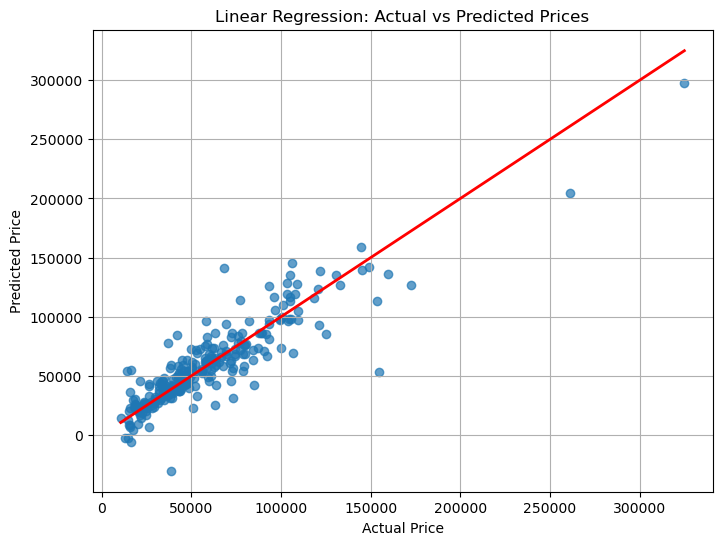

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test,lr_pred,alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Linear Regression: Actual vs Predicted Prices")

plt.grid()

plt.show()

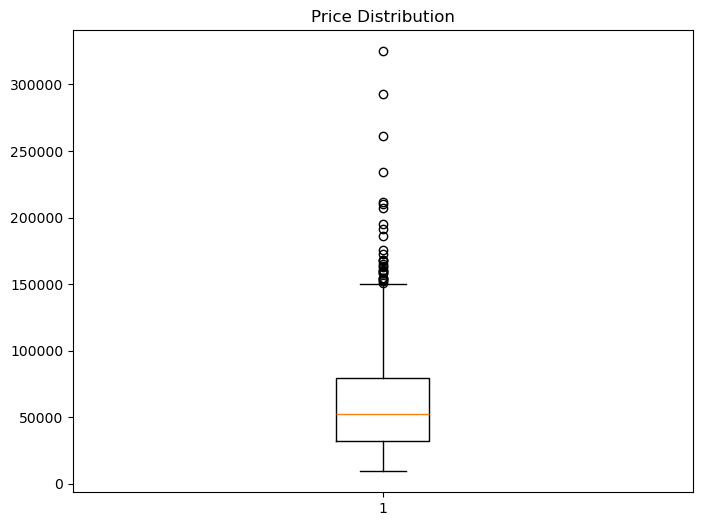

In [81]:
plt.figure(figsize=(8,6))

plt.boxplot(laptop["Price"])

plt.title("Price Distribution")

plt.show()

In [82]:
laptop[laptop["Price"] > 150000] ### OUTLİERS

,Inches,Price,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,Company_HP,Company_Huawei,...,Weight_4.2kg,Weight_4.33kg,Weight_4.36kg,Weight_4.3kg,Weight_4.42kg,Weight_4.4kg,Weight_4.5kg,Weight_4.6kg,Weight_4.7kg,Weight_4kg
17,15.4,152274.2400,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
190,14.0,150462.7200,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
196,17.3,324954.7200,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
204,15.6,162770.4000,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
238,17.3,207259.2000,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
247,17.3,159786.7200,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
297,17.3,153705.3408,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
517,15.6,158135.0400,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
530,17.3,160520.3856,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
563,17.3,159786.7200,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [83]:
laptop = laptop[laptop["Price"] < 150000]

In [84]:
X = laptop.drop("Price", axis=1)
y = laptop["Price"]

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [86]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [87]:
from sklearn.metrics import (r2_score,
    mean_absolute_error,
    mean_squared_error)

print("R2:",r2_score(y_test, lr_pred))
print("MAE:",mean_absolute_error(y_test, lr_pred))
print("MSE:",mean_squared_error(y_test, lr_pred))

R2: 0.848833972834969
MAE: 8815.21219896416
MSE: 152109596.9727335


In [88]:
### Decision Trees
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree R2:",r2_score(y_test, dt_pred))
print("Decision Tree MAE:",mean_absolute_error(y_test, dt_pred))
print("Decision Tree MSE:",mean_squared_error(y_test, dt_pred))

Decision Tree R2: 0.7496616582105584
Decision Tree MAE: 10559.527680000001
Decision Tree MSE: 251900939.58639854


In [89]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest R2:",r2_score(y_test, rf_pred))
print("Random Forest MAE:",mean_absolute_error(y_test, rf_pred))
print("Random Forest MSE:",mean_squared_error(y_test, rf_pred))

Random Forest R2: 0.8671863609591494
Random Forest MAE: 8171.9415633859935
Random Forest MSE: 133642654.27793975


In [90]:
from sklearn.ensemble import AdaBoostRegressor

ada = AdaBoostRegressor(random_state=42)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)
print("AdaBoost R2:",r2_score(y_test, ada_pred))
print("AdaBoost MAE:",mean_absolute_error(y_test, ada_pred))
print("AdaBoost MSE:",mean_squared_error(y_test, ada_pred))

AdaBoost R2: 0.6244042571474475
AdaBoost MAE: 15925.630074255723
AdaBoost MSE: 377940190.27571803


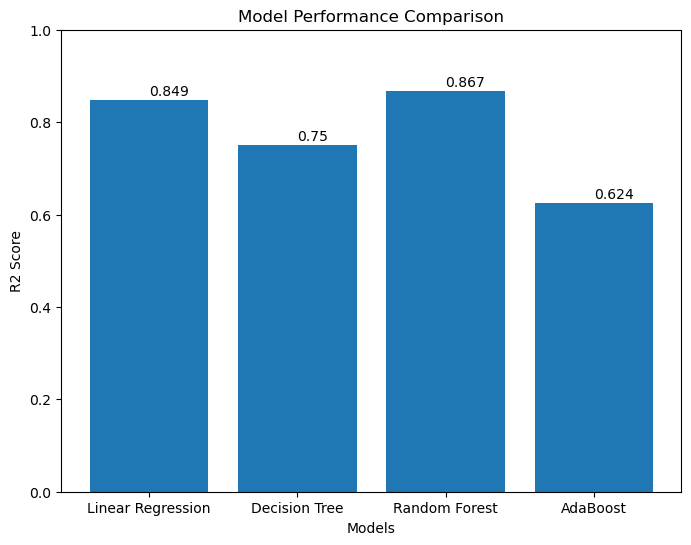

In [91]:
models = ["Linear Regression","Decision Tree","Random Forest","AdaBoost"]
scores = [r2_score(y_test, lr_pred),
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_pred),
    r2_score(y_test, ada_pred)]
plt.figure(figsize=(8,6))
plt.bar(models, scores)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Performance Comparison")
plt.ylim(0,1)
for i, v in enumerate(scores):plt.text(i, v + 0.01, round(v,3))
plt.show()

In [92]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_})

importance = importance.sort_values(
    by='Importance',
    ascending=False)

print(importance.head(10))

                         Feature  Importance
21             TypeName_Notebook    0.259276
180                     Ram_16GB    0.132705
184                      Ram_4GB    0.110136
0                         Inches    0.066584
187                      Ram_8GB    0.024529
305  Gpu_Nvidia GeForce GTX 1070    0.018135
216             Memory_512GB SSD    0.018067
197               Memory_1TB HDD    0.015803
183                     Ram_32GB    0.014533
23          TypeName_Workstation    0.014128


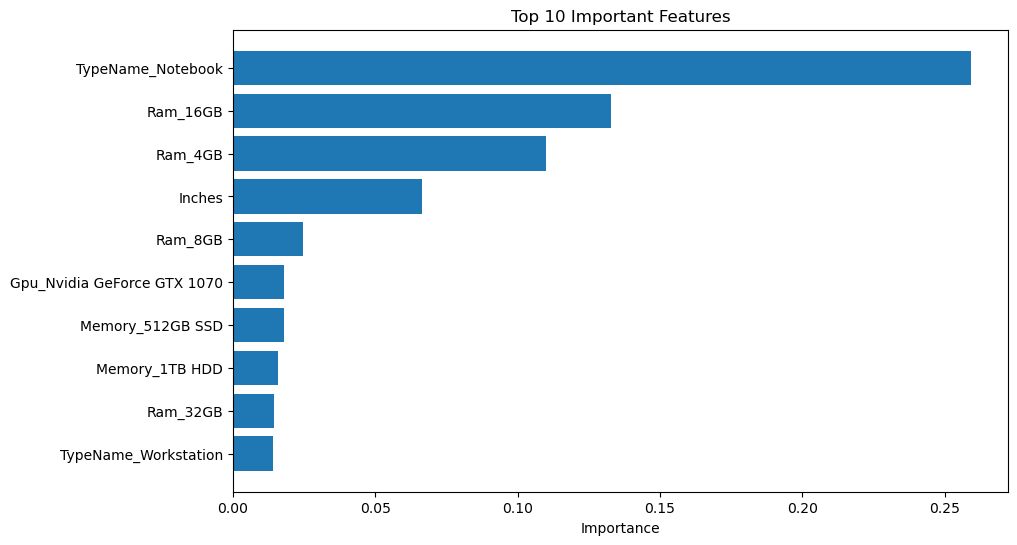

In [93]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance'])

plt.xlabel("Importance")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

In [94]:
# X ve y ayırma
X = laptop.drop("Price", axis=1)
y = laptop["Price"]

In [95]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [96]:
# Modeller ve metrikler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [97]:
# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Linear Regression")
print("R2:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))

Linear Regression
R2: 0.848833972834969
MAE: 8815.21219896416
MSE: 152109596.9727335


In [98]:
# 2. Decision Tree Regression
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("Decision Tree")
print("R2:", r2_score(y_test, dt_pred))
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("MSE:", mean_squared_error(y_test, dt_pred))

Decision Tree
R2: 0.7496616582105584
MAE: 10559.527680000001
MSE: 251900939.58639854


In [99]:
# 3. Random Forest Regression
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest")
print("R2:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))

Random Forest
R2: 0.8671863609591494
MAE: 8171.9415633859935
MSE: 133642654.27793975


In [100]:
# 4. AdaBoost Regression
ada = AdaBoostRegressor(random_state=42)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

print("AdaBoost")
print("R2:", r2_score(y_test, ada_pred))
print("MAE:", mean_absolute_error(y_test, ada_pred))
print("MSE:", mean_squared_error(y_test, ada_pred))

AdaBoost
R2: 0.6244042571474475
MAE: 15925.630074255723
MSE: 377940190.27571803


In [101]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring="r2",
    n_jobs=-1)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2: 0.7769104171232907


In [102]:
from sklearn.model_selection import GridSearchCV
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring="r2",
    n_jobs=-1)

grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2: 0.7769104171232907


In [105]:
# En iyi Random Forest modeli
best_rf = grid.best_estimator_
# Tahmin yap
best_rf_pred = best_rf.predict(X_test)
results = pd.DataFrame({
    "Model": ["Linear Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Best Random Forest"],
    "R2": [r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, ada_pred),
        r2_score(y_test, best_rf_pred)],
    "MAE": [mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, ada_pred),
        mean_absolute_error(y_test, best_rf_pred)],
    "MSE": [mean_squared_error(y_test, lr_pred),
        mean_squared_error(y_test, dt_pred),
        mean_squared_error(y_test, rf_pred),
        mean_squared_error(y_test, ada_pred),
        mean_squared_error(y_test, best_rf_pred)]})

results

,Model,R2,MAE,MSE
0,Linear Regression,0.848834,8815.212199,1.521096e+08
1,Decision Tree,0.749662,10559.527680,2.519009e+08
2,Random Forest,0.867186,8171.941563,1.336427e+08
3,AdaBoost,0.624404,15925.630074,3.779402e+08
4,Best Random Forest,0.866668,8216.989065,1.341644e+08


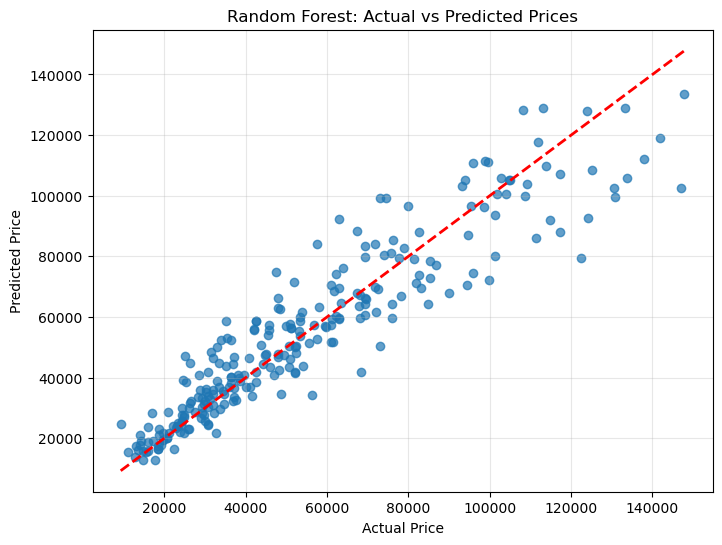

In [106]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    best_rf_pred,
    alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2,
    linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.grid(alpha=0.3)
plt.show()

##### Veri seti incelendiğinde bazı dizüstü bilgisayar fiyatlarının diğer verilere göre oldukça yüksek olduğu gözlemlenmiştir. Bu tür aşırı uç değerler (outliers), makine öğrenmesi modellerinin veri dağılımını doğru öğrenmesini zorlaştırabilmekte ve tahmin performansını olumsuz etkileyebilmektedir. Özellikle fiyat tahmini grafiklerinde yüksek fiyat aralıklarında tahmin sapmalarının arttığı görülmüştür. Bu nedenle veri setinde outlier analizi gerçekleştirilmiş ve modelin daha dengeli öğrenebilmesi amacıyla 150.000 üzerindeki fiyat değerleri veri setinden çıkarılmıştır. Böylece modellerin genel performansının ve tahmin doğruluğunun artırılması hedeflenmiştir.

#### Yapılan model karşılaştırmaları sonucunda Random Forest regresyon modelinin diğer modellere göre daha başarılı sonuçlar verdiği görülmüştür. Özellikle yüksek fiyat aralıklarında daha dengeli tahminler yapabilmiş ve gerçek fiyat değerlerine daha yakın sonuçlar üretmiştir.

Linear Regression modeli genel olarak başarılı sonuçlar vermesine rağmen doğrusal olmayan ilişkileri öğrenmede sınırlı kalmıştır. Decision Tree modeli bazı fiyat aralıklarında iyi performans gösterse de aşırı öğrenme (overfitting) eğilimi göstermiştir. AdaBoost modeli ise bazı durumlarda tahmin performansını artırsa da veri setindeki karmaşık ilişkileri Random Forest kadar başarılı şekilde öğrenememiştir.

Genel değerlendirme sonucunda Random Forest Regression modeli:

daha yüksek R² Score,
daha düşük MAE,
daha düşük MSE

değerleri elde ederek en başarılı model olarak belirlenmiştir. Bu sonuç, Random Forest modelinin farklı özellikler arasındaki karmaşık ilişkileri daha etkili şekilde öğrenebildiğini göstermektedir.